In [1]:
!pip install tf-levenberg-marquardt 

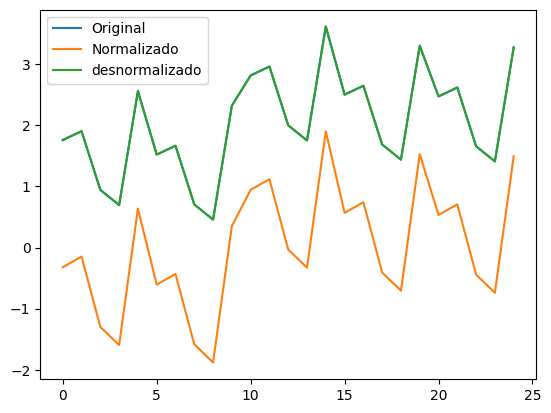

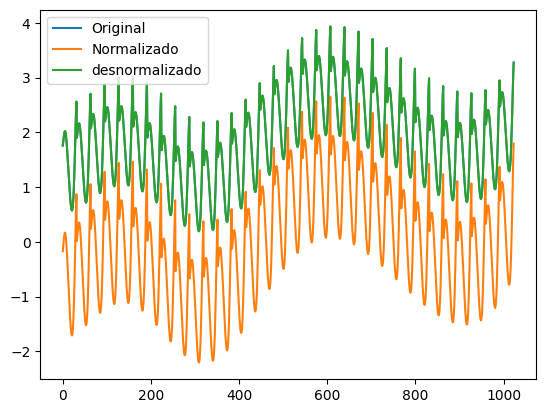

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid): 
    x = np.linspace(0, 1, grid)
    y = np.linspace(0, 1, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-12 11:42:46.296174: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 11:42:46.360153: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-12 11:42:46.360230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-12 11:42:46.362586: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 11:42:46.374098: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 11:42:46.375256: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[3, 4], [4, 2], [5, 3], [4, 4], [5, 5], [6, 5], [5, 6]],
            regularizers=[0.5, 0.3],
            learning_rate=[0.1, 0.5])

Testando combinacao1: Hidden Size=[3, 4], regularizer=0.5, learning_rate=0.1


+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  6
32/32 [===========

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_3,0.874714,0.666250,0.896596,0.930450,0.923986,0.074375,0.198128,0.056597,0.058276,0.057436,0.106414,0.272718,1.501145,0.284329,65.197262,101.763537
model_1_0_4,0.890435,0.576885,0.872730,0.827685,0.858362,0.065043,0.251179,0.069660,0.144383,0.107021,0.147468,0.255035,1.438261,0.265892,65.465422,102.031696
model_1_0_6,0.951483,0.561399,0.903380,0.879981,0.898460,0.028802,0.260372,0.052883,0.100564,0.076724,0.096758,0.169711,1.194068,0.176936,67.094639,103.660914
model_1_0_7,0.970423,0.546208,0.939197,0.936523,0.942783,0.017558,0.269391,0.033280,0.053187,0.043233,0.076514,0.132507,1.118308,0.138148,68.084476,104.650751
model_1_0_5,0.945438,0.541075,0.896648,0.863823,0.887062,0.032390,0.272438,0.056568,0.114103,0.085336,0.102898,0.179973,1.218247,0.187635,66.859800,103.426075
model_1_0_8,0.963887,0.522928,0.870330,0.942484,0.921145,0.021438,0.283211,0.070973,0.048193,0.059583,0.079228,0.146418,1.144451,0.152651,67.685169,104.251444
model_1_0_9,0.961588,0.522495,0.850563,0.942268,0.913866,0.022803,0.283467,0.081792,0.048374,0.065083,0.079979,0.151006,1.153647,0.157435,67.561739,104.128014
model_1_0_10,0.958187,0.521108,0.824972,0.941350,0.904088,0.024822,0.284291,0.095799,0.049143,0.072471,0.081614,0.157549,1.167251,0.164257,67.392066,103.958340
model_1_0_11,0.954201,0.519116,0.796741,0.939913,0.893066,0.027188,0.285473,0.111251,0.050347,0.080799,0.083473,0.164889,1.183196,0.171908,67.209939,103.776214
model_1_0_12,0.949380,0.516717,0.763791,0.938246,0.880208,0.030051,0.286898,0.129285,0.051744,0.090515,0.085685,0.173351,1.202482,0.180731,67.009752,103.576026


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 1s 19ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 11ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 13ms/step
+++++++++++ [1_1] | 9 ++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_8,0.953490,0.506358,0.853779,0.930666,0.899222,0.027610,0.293047,0.054988,0.037136,0.046062,0.086862,0.166164,1.186041,0.173238,67.179119,103.745394
model_1_1_9,0.957498,0.506186,0.859420,0.927692,0.899801,0.025231,0.293149,0.052867,0.038729,0.045798,0.082167,0.158843,1.170009,0.165605,67.359353,103.925628
model_1_1_7,0.948538,0.505468,0.847888,0.933103,0.898226,0.030550,0.293576,0.057204,0.035831,0.046517,0.092475,0.174785,1.205846,0.182226,66.976796,103.543071
model_1_1_10,0.960756,0.505203,0.864874,0.924421,0.900128,0.023297,0.293733,0.050816,0.040481,0.045648,0.077864,0.152632,1.156974,0.159130,67.518891,104.085165
model_1_1_11,0.963412,0.503605,0.870157,0.921013,0.900304,0.021720,0.294682,0.048829,0.042306,0.045568,0.073921,0.147378,1.146352,0.153652,67.659027,104.225302
model_1_1_6,0.942407,0.503244,0.841723,0.934676,0.896612,0.034189,0.294896,0.059523,0.034988,0.047255,0.099014,0.184904,1.230370,0.192776,66.751677,103.317951
model_1_1_12,0.965581,0.501552,0.875264,0.917575,0.900391,0.020433,0.295900,0.046909,0.044147,0.045528,0.070313,0.142944,1.137678,0.149029,67.781223,104.347497
model_1_1_5,0.934824,0.499515,0.835402,0.935001,0.894202,0.038691,0.297110,0.061900,0.034814,0.048357,0.106116,0.196701,1.260703,0.205075,66.504288,103.070562
model_1_1_13,0.967353,0.499188,0.880180,0.914173,0.900420,0.019380,0.297303,0.045060,0.045970,0.045515,0.067010,0.139214,1.130586,0.145140,67.886984,104.453258
model_1_1_14,0.968804,0.496653,0.884880,0.910861,0.900413,0.018520,0.298809,0.043293,0.047744,0.045518,0.063986,0.136086,1.124785,0.141880,67.977861,104.544136


...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  36
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 5ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 5ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_8] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_12,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_22,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_21,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_20,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_19,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_18,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_17,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_16,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_15,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678
model_28_8_14,0.986143,0.605894,0.990413,0.949209,0.969234,0.008226,0.233958,0.007649,0.043764,0.025707,0.032099,0.090698,1.009781,0.094559,125.600880,196.295678


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  10
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 9ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_9] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_24,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_22,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_21,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_20,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_19,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_18,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_17,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_23,0.993069,0.622581,0.945226,0.972401,0.979780,0.004115,0.224052,0.016665,0.009052,0.012858,0.022409,0.064145,1.004893,0.066876,126.986416,197.681213
model_28_9_16,0.993069,0.622581,0.945227,0.972402,0.979780,0.004115,0.224052,0.016664,0.009052,0.012858,0.022409,0.064145,1.004892,0.066876,126.986450,197.681248
model_28_9_15,0.993070,0.622581,0.945232,0.972403,0.979781,0.004114,0.224052,0.016663,0.009051,0.012857,0.022409,0.064142,1.004892,0.066873,126.986608,197.681406


DataFrame salvo em content/results/metrics_28_9
